In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 生成双峰数据（两个正态分布的混合）
np.random.seed(42)
data1 = np.random.normal(loc=10, scale=2, size=500)  # 第一个峰（均值10，方差4）
data2 = np.random.normal(loc=30, scale=3, size=500)  # 第二个峰（均值30，方差9）
data = np.concatenate([data1, data2])  # 合并数据

In [2]:
from scipy.stats import norm
from scipy.optimize import curve_fit

def bimodal_distribution(x, mu1, sigma1, mu2, sigma2, weight):
    """双峰正态分布函数：两个高斯分布的加权和"""
    return weight * norm.pdf(x, mu1, sigma1) + (1 - weight) * norm.pdf(x, mu2, sigma2)

In [6]:
from scipy.signal import find_peaks
# 计算直方图密度
hist, bin_edges = np.histogram(data, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 寻找直方图的峰值（双峰位置）
peaks, _ = find_peaks(hist, height=0.01)  # height阈值过滤噪声
mu_guess = bin_centers[peaks]  # 初步估计均值
sigma_guess = [np.std(data[(data > mu_guess[i]-5) & (data < mu_guess[i]+5)]) for i in range(2)]  # 局部标准差
weight_guess = [len(data[(data > mu_guess[i]-5) & (data < mu_guess[i]+5)])/len(data) for i in range(2)]

initial_guess = [mu_guess[0], sigma_guess[0], mu_guess[1], sigma_guess[1], weight_guess[0]]

# 拟合双峰分布
params, cov = curve_fit(bimodal_distribution, bin_centers, hist, p0=initial_guess)
mu1, sigma1, mu2, sigma2, weight = params

print(f"峰1: 均值 = {mu1:.2f}, 方差 = {sigma1**2:.2f}")
print(f"峰2: 均值 = {mu2:.2f}, 方差 = {sigma2**2:.2f}")

峰1: 均值 = 9.97, 方差 = 3.84
峰2: 均值 = 30.05, 方差 = 8.48


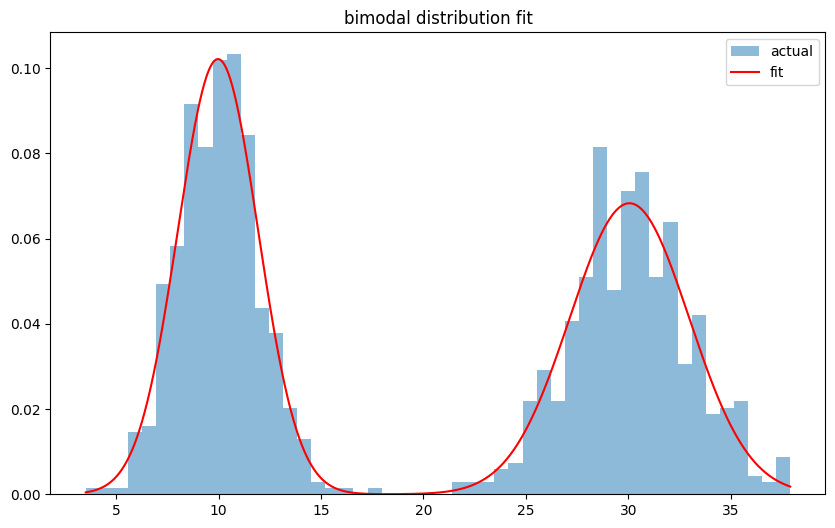

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.5, label='actual')
x = np.linspace(min(data), max(data), 1000)
plt.plot(x, bimodal_distribution(x, *params), 'r-', label='fit')
plt.legend()
plt.title('bimodal distribution fit')
plt.show()

In [ ]:
def bimodal_distribution(x, mu1, sigma1, mu2, sigma2, weight):
    """双峰正态分布函数：两个高斯分布的加权和"""
    return weight * norm.pdf(x, mu1, sigma1) + (1 - weight) * norm.pdf(x, mu2, sigma2)

In [ ]:
from scipy.signal import find_peaks
def create_tg_cond_mask(arr, t, tg, input_mask=None):
    # 如果没有提供input_mask，则创建全True掩码
    if input_mask is None:
        input_mask = np.ones_like(arr, dtype=bool)
    masked_arr = arr[input_mask]
    data = masked_arr.flatten()
    return_mu, return_mask = None, None
    # 计算直方图密度
    hist, bin_edges = np.histogram(data, bins=50, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 寻找直方图的峰值位置
    peaks, _ = find_peaks(hist, height=0.001)  # height阈值过滤噪声
    mu_guess = bin_centers[peaks]  # 初步估计均值
    print(f"Peak num = {mu_guess.size}")
    if mu_guess.size == 1:  # 单峰
        mu, sigma = norm.fit(data)
        return_mu = mu
        # 计算有效范围
        lower_bound = mu - t
        upper_bound = mu + t
        # 计算范围并生成掩码（仅当值在范围内且input_mask为True时返回True）
        range_mask = (arr >= lower_bound) & (arr <= upper_bound)
        return_mask = range_mask & input_mask

        plt.figure(figsize=(10, 6))
        plt.hist(data, bins=50, density=True, alpha=0.5, color='b', label='actual dist')
        # 绘制拟合曲线
        x = np.linspace(min(data), max(data), 1000)
        pdf = norm.pdf(x, mu, sigma)  # 计算概率密度
        plt.plot(x, pdf, 'r-', linewidth=2, label='fit dist')
        plt.title(f"tg_{tg}: mu={np.mean(data):.2f}, sigma={np.var(data):.2f}\nfit_mu1={mu}, fit_sigma1={sigma}")
        plt.xlabel("Conductance (uS)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()
    elif mu_guess.size >= 2:
        sigma_guess = [np.std(data[(data > mu_guess[i]-5) & (data < mu_guess[i]+5)]) for i in range(2)]  # 局部标准差
        weight_guess = [len(data[(data > mu_guess[i]-5) & (data < mu_guess[i]+5)])/len(data) for i in range(2)]
        initial_guess = [mu_guess[0], sigma_guess[0], mu_guess[1], sigma_guess[1], weight_guess[0]]
        # 拟合双峰分布
        params, cov = curve_fit(bimodal_distribution, bin_centers, hist, p0=initial_guess)
        mu1, sigma1, mu2, sigma2, weight = params
        return_mu = mu1
        # 计算有效范围
        lower_bound = mu1 - t
        upper_bound = mu1 + t
        # 计算范围并生成掩码（仅当值在范围内且input_mask为True时返回True）
        range_mask = (arr >= lower_bound) & (arr <= upper_bound)
        return_mask = range_mask & input_mask

        plt.figure(figsize=(10, 6))
        plt.hist(data, bins=50, density=True, alpha=0.5, color='b', label='actual dist')
        # 绘制拟合曲线
        x = np.linspace(min(data), max(data), 1000)
        plt.plot(x, bimodal_distribution(x, *params), 'r-', label='fit dist')
        plt.title(f"tg_{tg}: mu1={mu_guess[0]:.2f}, sigma1={sigma_guess[0]:.2f}\nfit_mu1={mu1}, fit_sigma1={sigma1}")
        plt.xlabel("Conductance (uS)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()
    else:
        return_mask = input_mask
    # with printoptions(threshold=np.inf):  # 仅在此上下文生效
    #     print(counts)
    
    return return_mu, return_mask

In [ ]:
def Set(chip,need_read,write_times,write_voltage,start_tg,delta_tg,threshold,set_pulse_width,sub_base=True,vmax=1000,plot_cond=None):
    cond_all = np.zeros_like(need_read,dtype=float)
    final_mask = np.ones_like(need_read,dtype=bool)
    tg_cond = {}
    for i in range(write_times):
        print(f"write_time = {i}")
        tg = start_tg+i*delta_tg
        chip.write4(crossbar=need_read,row_index=None,col_index=None,write_voltage=write_voltage,tg=tg,pulse_width=set_pulse_width,set_device=True,split_type=0,row_type=0,col_type=0)
        
        _,cond,_ = chip.read4(crossbar=need_read,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=sub_base,from_row=True,split_type=0,row_type=0,col_type=0)
        np.save(f'../data/good_device/tg_cond2/tg_{tg}_cond.npy', cond[need_read])
        fit_mu1, cond_mask = create_tg_cond_mask(cond, 50, tg, need_read & (cond<1000))
        tg_cond[tg] = fit_mu1
        final_mask = final_mask & cond_mask
        print(f"# of devices in range of +-50: {np.sum(final_mask)}")
        # if plot_cond: plot_cond(cond,title=f"tg={tg:.2f}-GoodDevices={np.sum(final_mask)}",vmax=vmax)
    return final_mask, tg_cond

write_time = 0


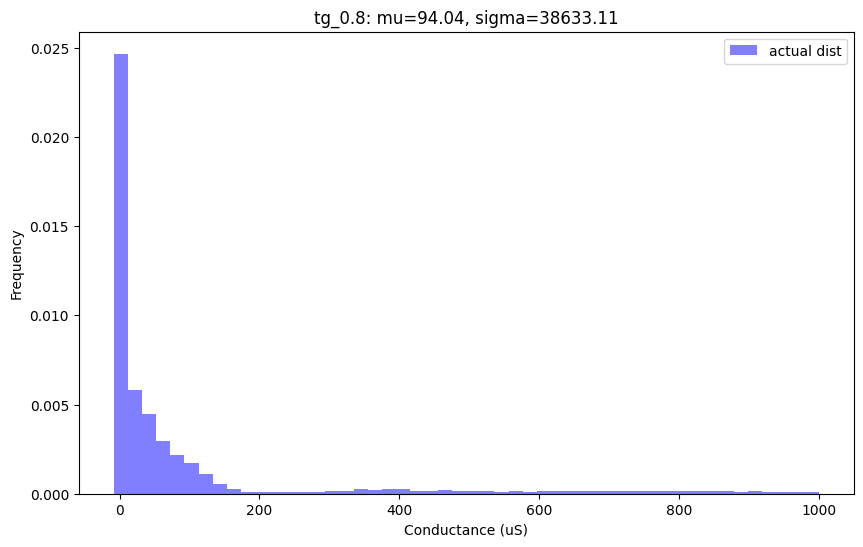

write_time = 1


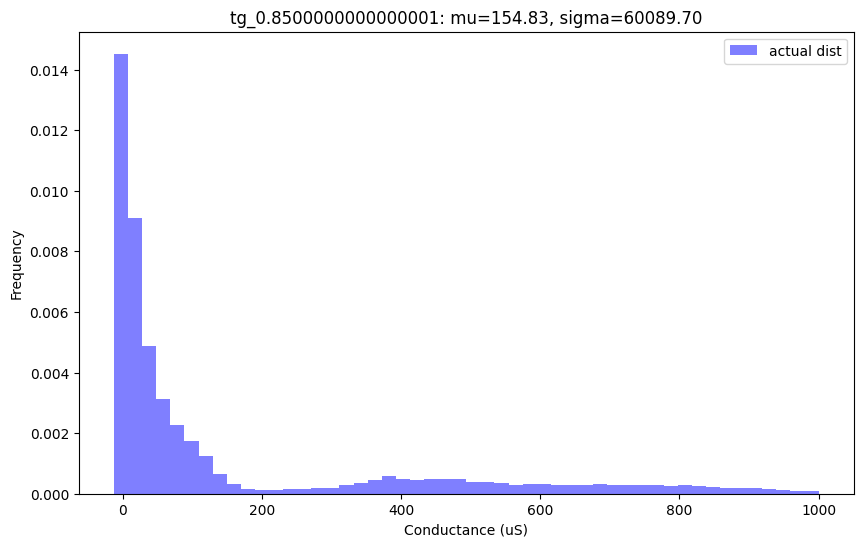

write_time = 2


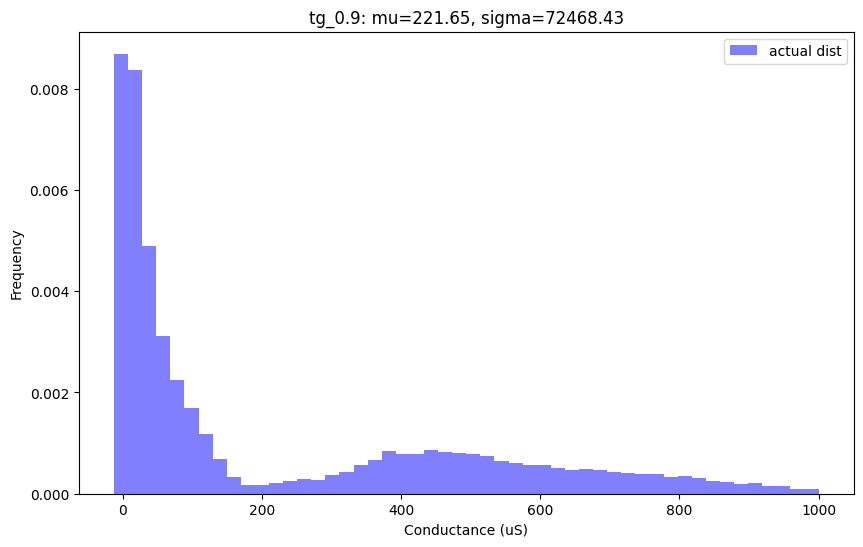

write_time = 3


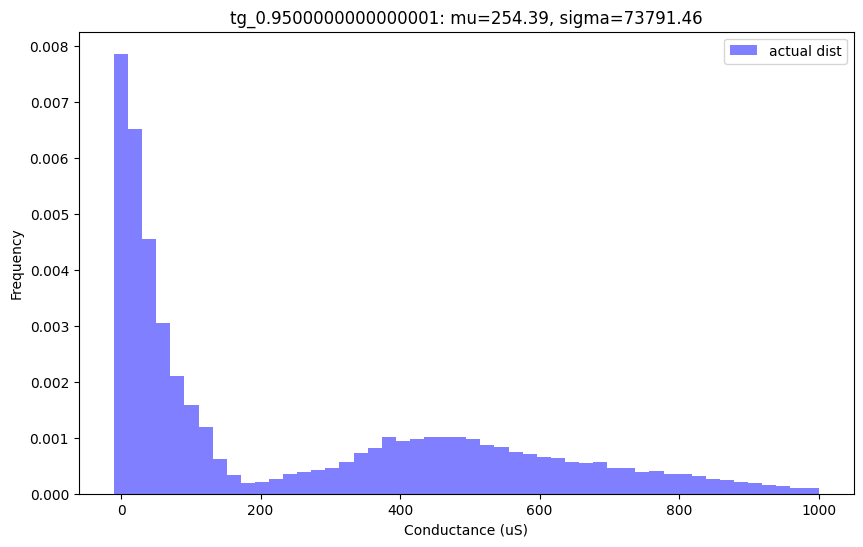

write_time = 4


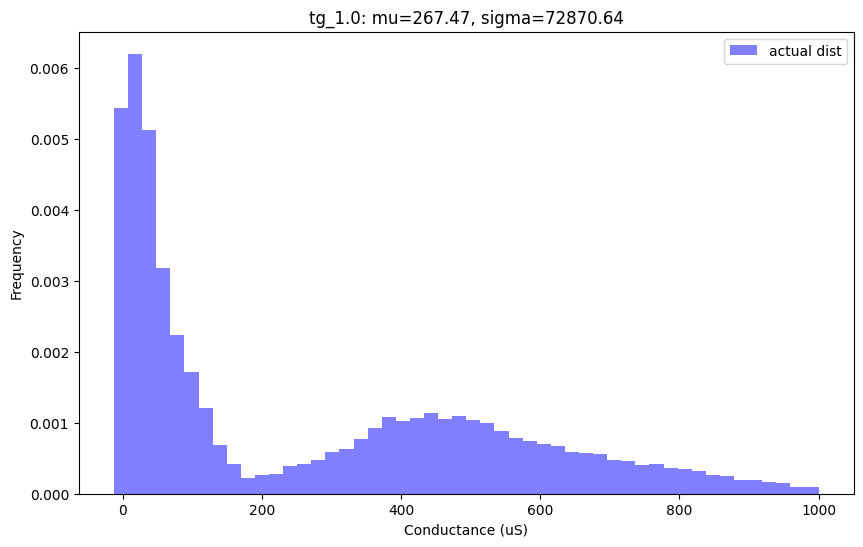

write_time = 5


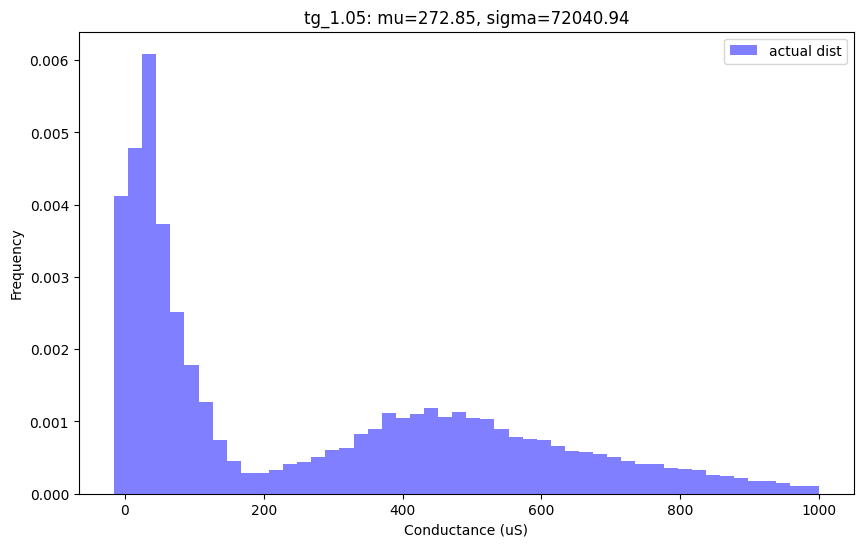

write_time = 6


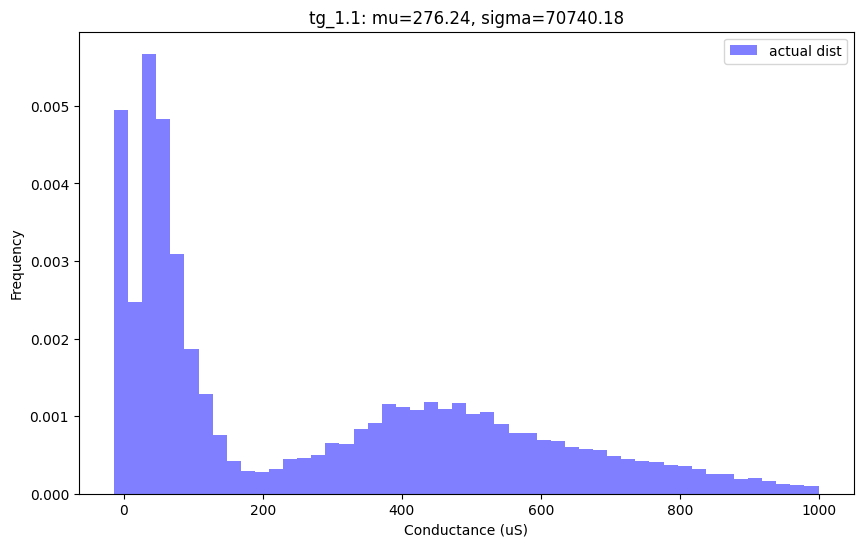

write_time = 7


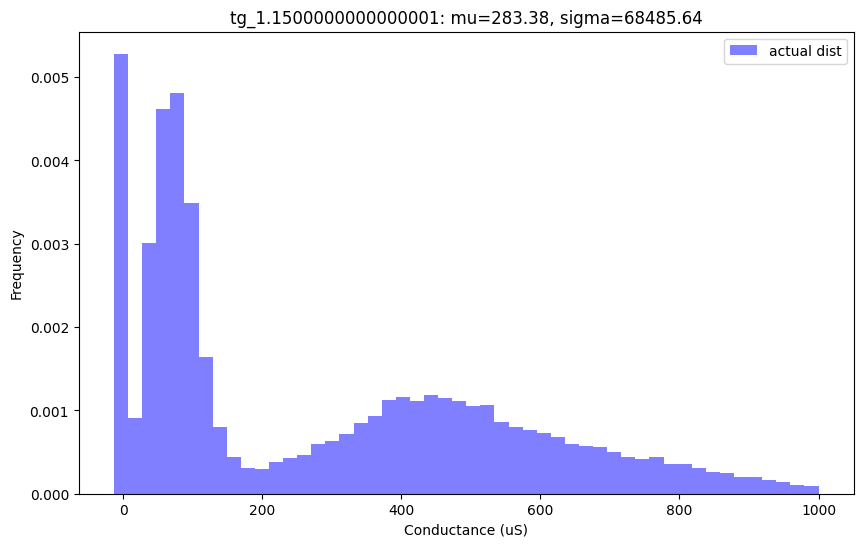

write_time = 8


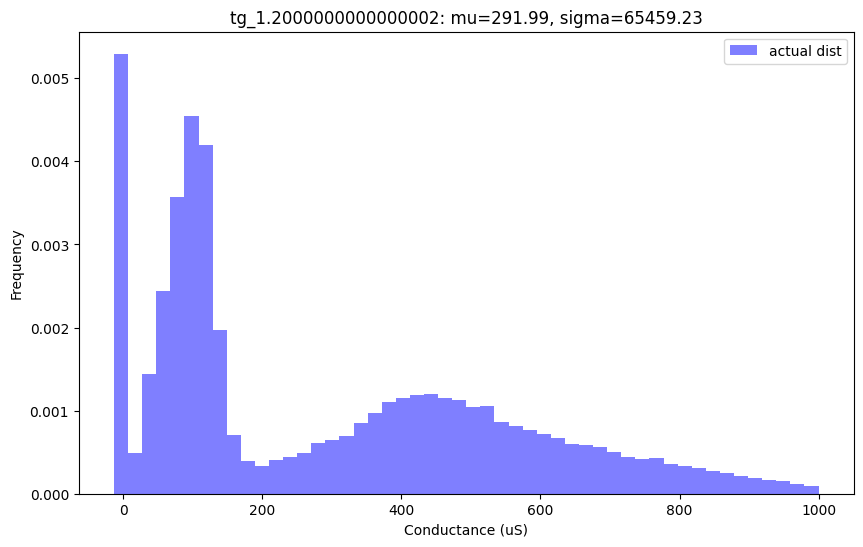

write_time = 9


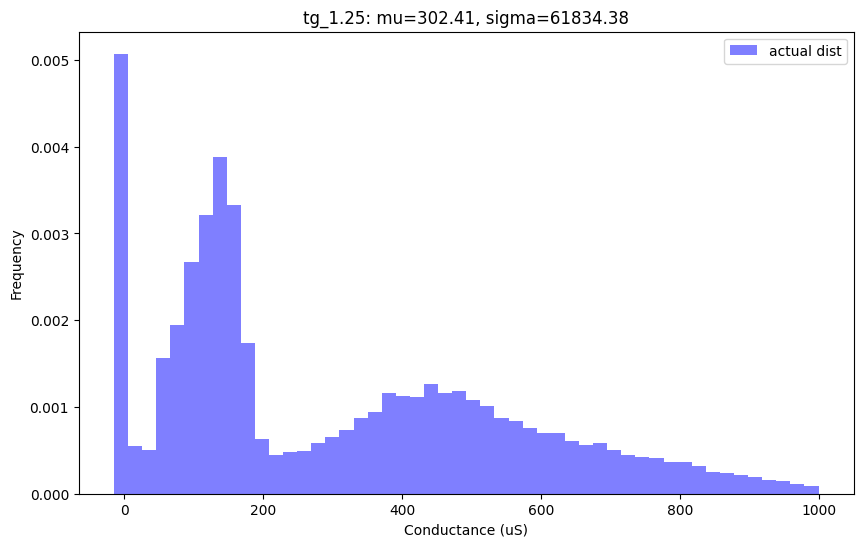

write_time = 10


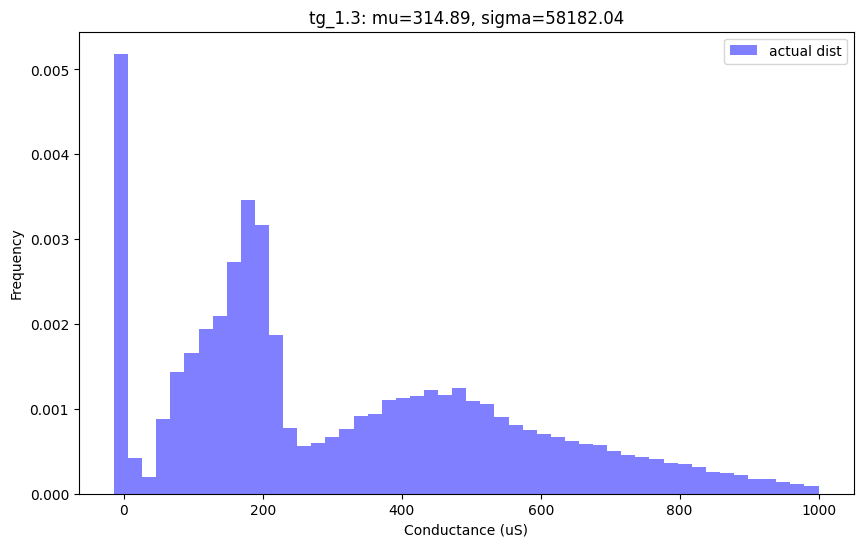

write_time = 11


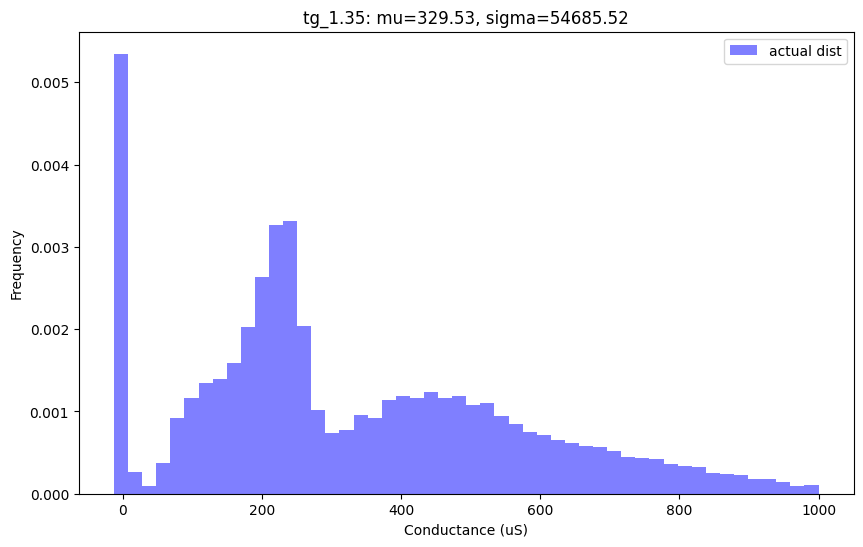

write_time = 12


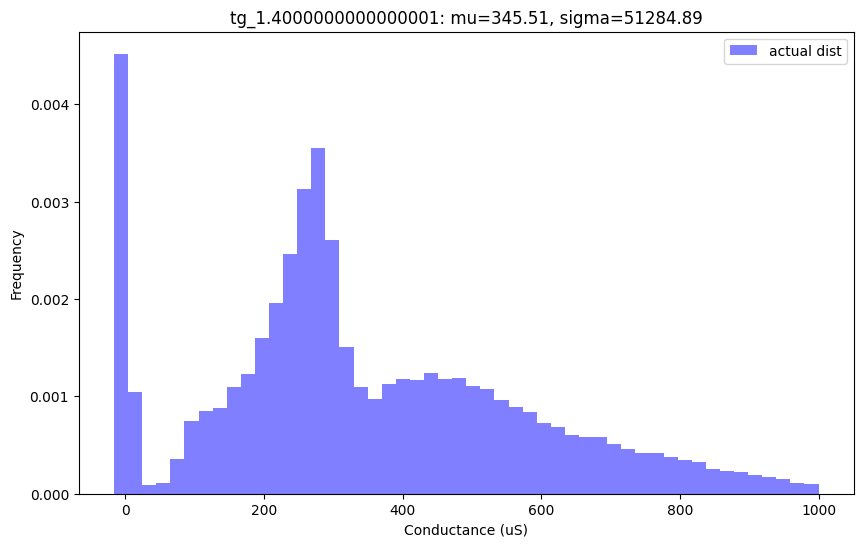

write_time = 13


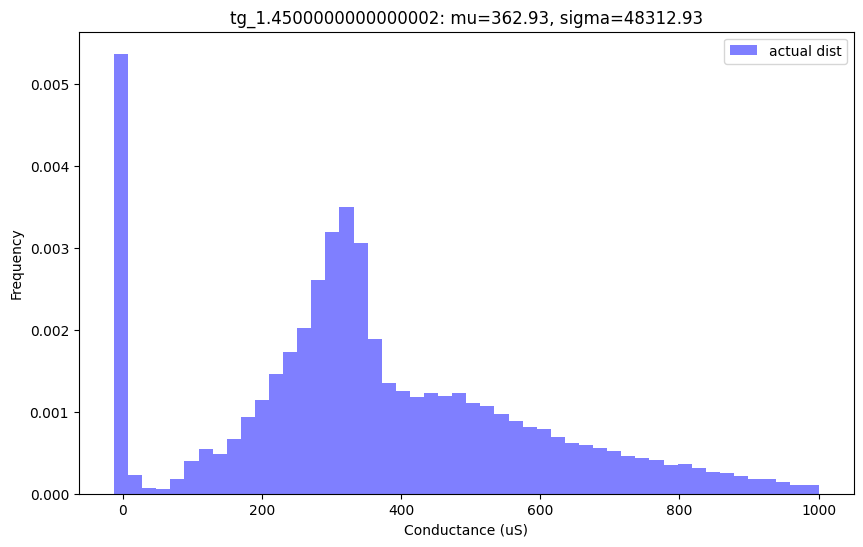

write_time = 14


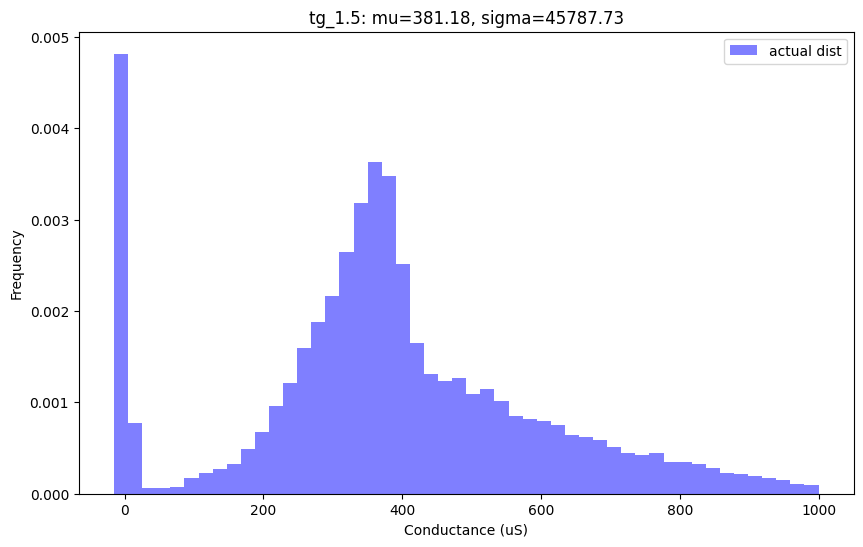

write_time = 15


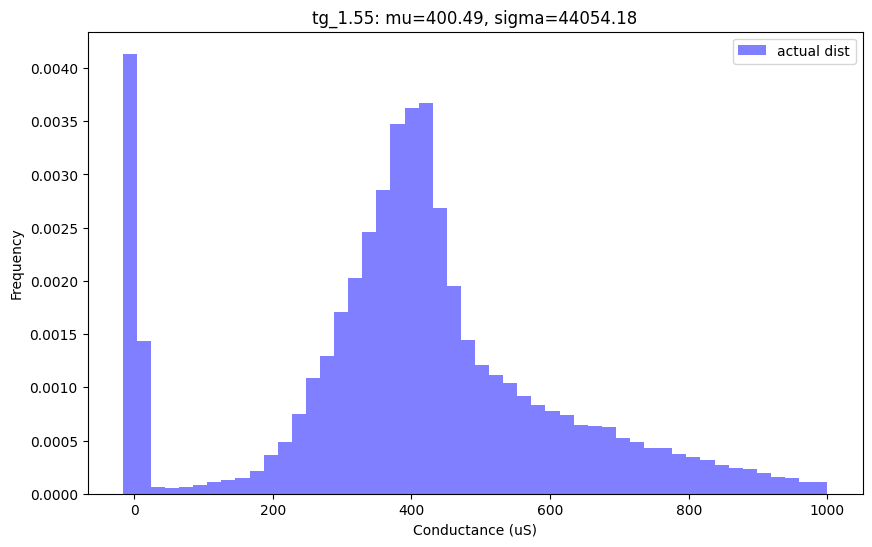

write_time = 16


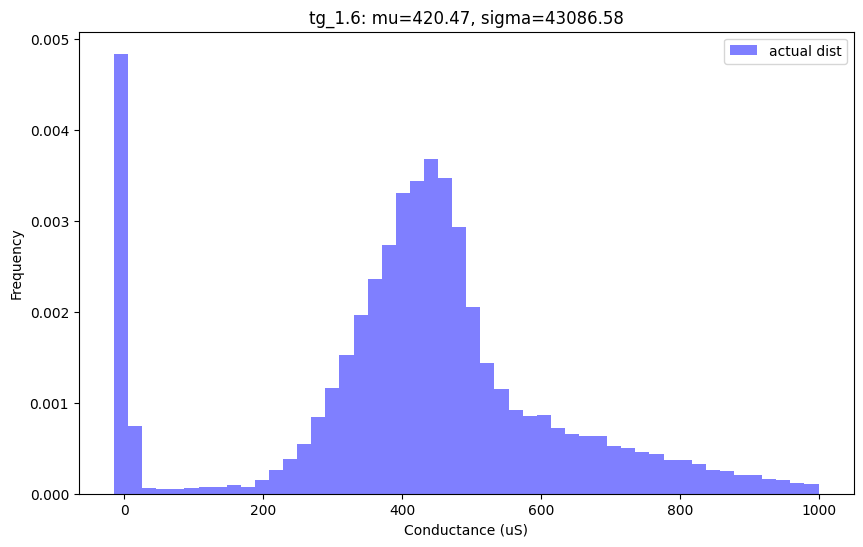

write_time = 17


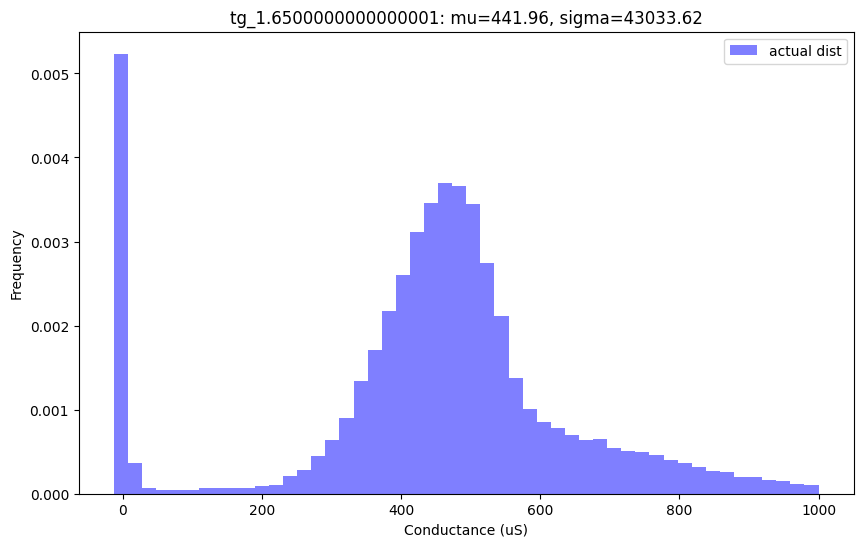

write_time = 18


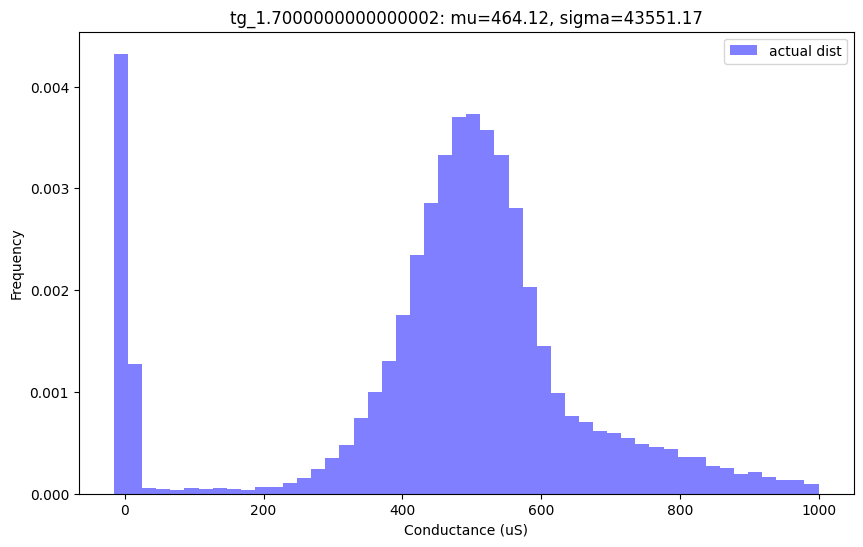

write_time = 19


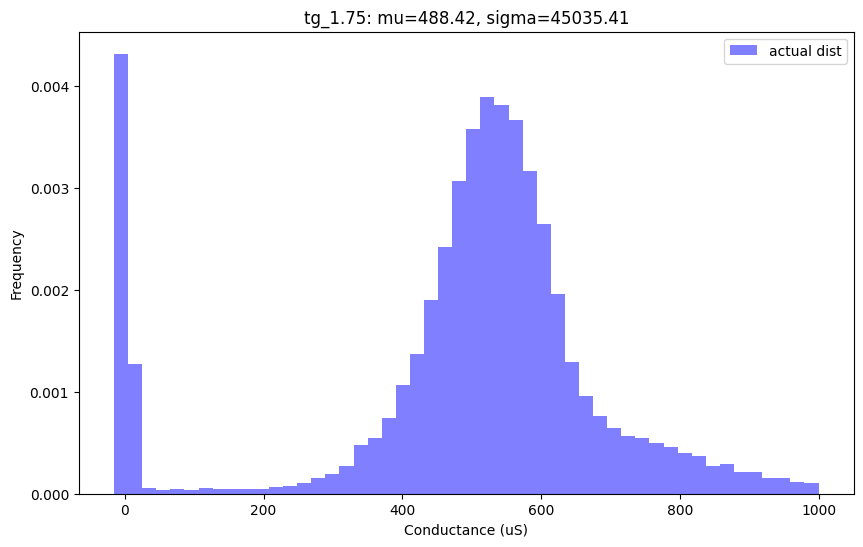

write_time = 20


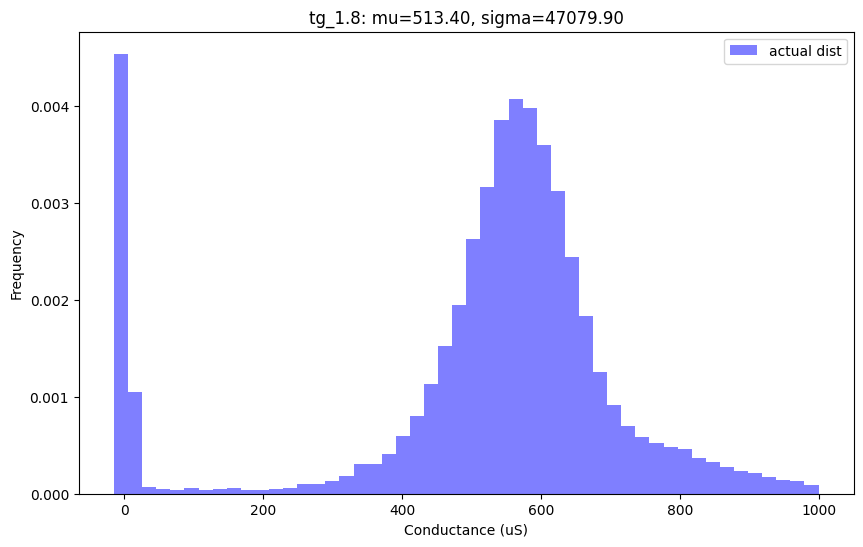

In [ ]:
# crossbar = np.ones((256,256),dtype=bool)
crossbar = np.load("../data/good_device/20250621_cond_reset_200_set_500.npy")
final_mask, tg_cond = Set(chip=chip,need_read=crossbar,write_times=21,write_voltage=3,start_tg=0.8,delta_tg=0.05,threshold=600,set_pulse_width=1e-6,sub_base=True,vmax=1000,plot_cond=plot_cond)